# SILVA Poisson Mirror Equilibrium

This lab derives the Poisson data term, the Burg mirror map, its closed-form
positive update, and the fixed-point reconstruction. It verifies a seeded
Poisson imaging problem and compares data fidelity before and after the
equilibrium. The mechanism follows DEQ-MD [[50]](https://jseluis.github.io/silva-networks/paper/references/#ref-50) inside SILVA.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[50]](https://jseluis.github.io/silva-networks/paper/references/#ref-50). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVABurgMirrorTransition,
    SILVAPoissonMirrorEquilibrium,
    SolverConfig,
    make_poisson_inverse_dataset,
    poisson_kl,
)

torch.manual_seed(230)

## 1. Poisson Observation Model

For nonnegative image $x$ and forward operator $A$,

$$
y_i\sim\operatorname{Poisson}((Ax)_i).
$$

Ignoring terms independent of $x$, the data fidelity is the generalized KL
divergence

$$
D_{\mathrm{KL}}(y,Ax)
=\sum_i y_i\log\frac{y_i}{(Ax)_i}+(Ax)_i-y_i.
$$

Its gradient is

$$
\nabla_xD_{\mathrm{KL}}=A^T\left(1-\frac{y}{Ax}\right).
$$

In [3]:
data = make_poisson_inverse_dataset(samples=3, height=8, width=8, exposure=30, seed=23)
assert data.expected_equation_residual().abs().max() == 0
assert data.clean.min() > 0 and data.observation.min() >= 0
print("clean/observed:", tuple(data.clean.shape), tuple(data.observation.shape))
print("clean-image KL:", float(data.data_fidelity(data.clean)))

clean/observed: (3, 1, 8, 8) (3, 1, 8, 8)
clean-image KL: 0.016562730073928833


## 2. Why Euclidean Descent Is Not the Same Update

Ordinary gradient descent adds a vector in Euclidean coordinates. Burg entropy

$$
h(x)=-\sum_i\log x_i,
\qquad \nabla h(x)=-x^{-1},
$$

defines geometry on the positive orthant. A mirror step with learned
regularizer gradient $r_\theta(x)$ is

$$
x^+=\nabla h^*\left(
\nabla h(x)-\tau[\nabla D_{\mathrm{KL}}+r_\theta(x)]
\right).
$$

## 3. Closed-Form Burg Update

Substituting $\nabla h(x)=-1/x$ gives

$$
x^+
=\frac{x}{1+\tau x\odot
\left[A^T\left(1-\frac{y}{Ax}\right)+r_\theta(x)\right]}.
$$

`SILVABurgMirrorTransition` applies this expression and a positive box
projection. The denominator floor is a numerical safeguard for compact runs;
full experiments should report any line search or backtracking policy.

In [4]:
transition = SILVABurgMirrorTransition(
    forward_operator=data.forward_operator,
    adjoint_operator=data.adjoint_operator,
    step_size=0.05,
    minimum=1e-4,
    maximum=3.0,
)
initial = data.observation.clamp_min(1e-4)
one_step = transition(initial, data.observation)
assert one_step.min() > 0
print("KL before/after one mirror step:",
      float(poisson_kl(data.observation, data.forward_operator(initial))),
      float(poisson_kl(data.observation, data.forward_operator(one_step))))

KL before/after one mirror step: 0.005836570169776678 0.005766694899648428


## 4. Mirror Step as a SILVA Equilibrium

The source is the observed count field $y$. The local/global field is the
forward-adjoint physics pair $A,A^T$. The self branch is the optional learned
regularizer gradient. Reusing the mirror transition gives

$$
x^\star=T_{\mathrm{Burg}}(x^\star;y).
$$

At a positive interior fixed point, the combined data and regularizer gradient
vanishes.

In [5]:
model = SILVAPoissonMirrorEquilibrium(
    transition=transition,
    config=SolverConfig(
        solver="picard",
        max_iter=20,
        tol=1e-6,
        anderson_batch_dims=1,
    ),
)
result = model(data.observation, z0=initial, return_result=True)
final_kl = poisson_kl(data.observation, result.intensity)
assert result.output.min() > 0
print("equilibrium residual:", result.solver_result.residual)
print("final KL:", float(final_kl))

equilibrium residual: 0.012612477876245975
final KL: 0.004821363836526871


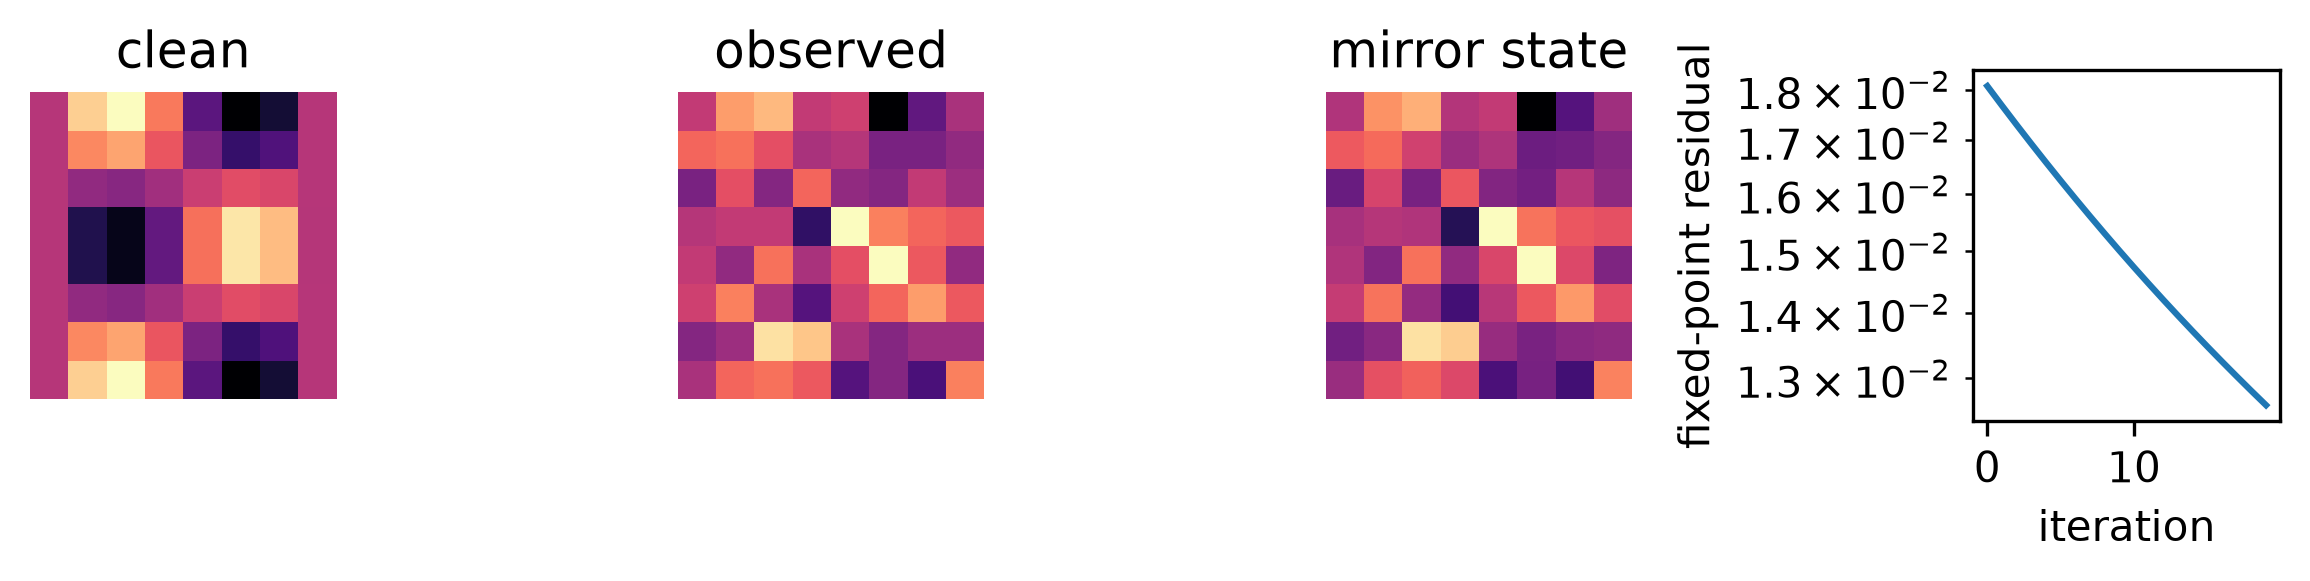

In [6]:
figure, axes = plt.subplots(1, 4, figsize=(7.8, 2.0))
axes[0].imshow(data.clean[0, 0], cmap="magma")
axes[0].set_title("clean")
axes[1].imshow(data.observation[0, 0], cmap="magma")
axes[1].set_title("observed")
axes[2].imshow(result.output.detach()[0, 0], cmap="magma")
axes[2].set_title("mirror state")
axes[3].semilogy(result.solver_result.residuals)
axes[3].set(xlabel="iteration", ylabel="fixed-point residual")
for axis in axes[:3]:
    axis.axis("off")
figure.tight_layout()
plt.show()

## 5. Learned Regularizer Contract

`regularizer_gradient` must preserve the image shape and return a gradient-like
field. A convolutional network, U-Net, or another SILVA point architecture can
occupy this branch. If the module is intended to be the gradient of a scalar
regularizer, that integrability claim requires a separate check; shape
preservation alone does not prove it.

## 6. Reproduction Checklist

Report the sensing operator and adjoint test, count scaling, exposure, box
bounds, mirror step, denominator or line-search safeguard, equilibrium solver,
residual, reconstruction metric, and learned regularizer architecture. This
small dataset validates the implementation path; it is not a medical or
astronomical benchmark.

## From 23 Silva Poisson Mirror Equilibrium to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | a positive reconstruction |
| Condition | observed counts and forward/adjoint measurement operators |
| Repeated computation | a Burg-geometry mirror transition with a learned or known regularizer |
| Required invariants | positivity, adjoint consistency, finite intensity, and box constraints |
| Replaceable components | initializer, forward/adjoint operators, regularizer, mirror transition, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Inverse Operator and Mirror Transition

```python
transition = SILVABurgMirrorTransition(
    forward_operator=my_forward_operator,
    adjoint_operator=my_adjoint_operator,
    regularizer_gradient=my_regularizer_gradient,
    step_size=step_size,
)
model = SILVAPoissonMirrorEquilibrium(
    transition=transition,
    initializer=my_positive_initializer,
    intensity_operator=my_forward_operator,
    config=solver_config,
)
```

For a completely different positive-domain update, replace `transition`
directly with a module implementing `(state, observation) -> next_state`.


In [7]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**Poisson divergence, reconstruction error, data residual, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **measurement count, image size, operator cost, and regularizer width**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [8]:
notebook_reproduction_record = {
    "notebook": '23_silva_poisson_mirror_equilibrium.ipynb',
    "state": 'a positive reconstruction',
    "condition": 'observed counts and forward/adjoint measurement operators',
    "transition": 'a Burg-geometry mirror transition with a learned or known regularizer',
    "invariants": 'positivity, adjoint consistency, finite intensity, and box constraints',
    "compact_metric": 'Poisson divergence, reconstruction error, data residual, and fixed-point residual',
    "scale_axis": 'measurement count, image size, operator cost, and regularizer width',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '23_silva_poisson_mirror_equilibrium.ipynb',
 'state': 'a positive reconstruction',
 'condition': 'observed counts and forward/adjoint measurement operators',
 'transition': 'a Burg-geometry mirror transition with a learned or known regularizer',
 'invariants': 'positivity, adjoint consistency, finite intensity, and box constraints',
 'compact_metric': 'Poisson divergence, reconstruction error, data residual, and fixed-point residual',
 'scale_axis': 'measurement count, image size, operator cost, and regularizer width'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **projected feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **a positive reconstruction**, and its repeated map,
**a Burg-geometry mirror transition with a learned or known regularizer**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [9]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('projected feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


projected feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


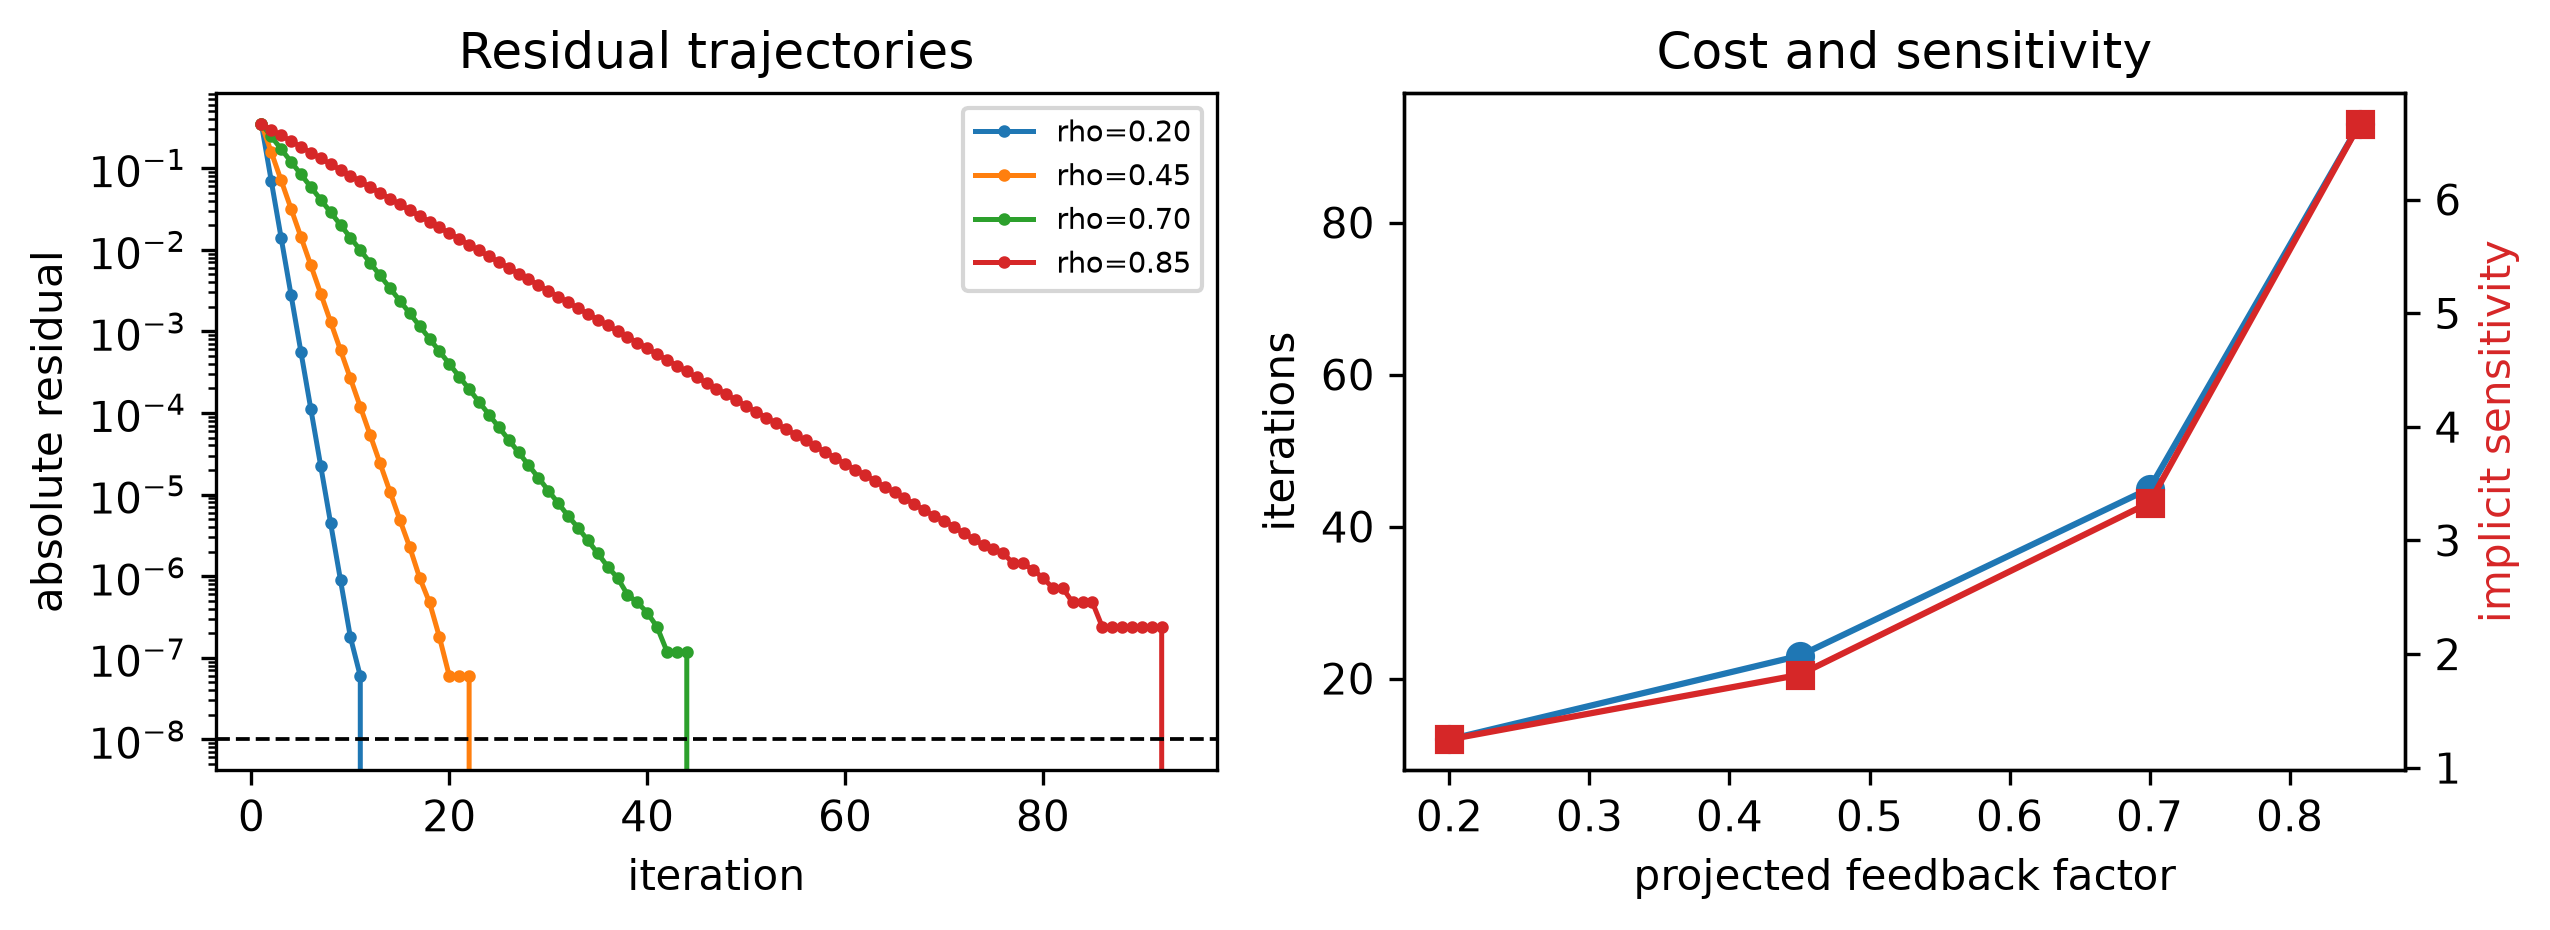

In [10]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('projected feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the projected feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | Poisson divergence, reconstruction error, data residual, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | positivity, adjoint consistency, finite intensity, and box constraints |
| Scale sweep | Change one of measurement count, image size, operator cost, and regularizer width at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is the Burg update derived? | [Advanced Equilibrium Families](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-families/#poisson-mirror-equilibrium) |
| How are the seeded Poisson observations generated? | [Advanced Equilibrium Datasets](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-datasets/#poisson-inverse-images) |
| Which mirror and KL objects are public? | [Physics-Informed API](https://jseluis.github.io/silva-networks/api/physics_informed/) |
